In [25]:
import xarray as ar
import pandas as pd
from netCDF4 import Dataset,num2date
ds = Dataset('A:\weather_net\dataset\IMDAA_merged_1.08_1990_2020.nc',mode='r')
df = pd.DataFrame()

In [26]:
for i in ds.variables.keys():
    print(ds.variables[i])

<class 'netCDF4.Variable'>
float32 HGT_prl(time, latitude, longitude)
    _FillValue: nan
    long_name: Geopotential Height
    units: m
    short_name: HGT
    level: pressure level
    coordinates: lon lat plevel
unlimited dimensions: 
current shape = (45292, 32, 32)
filling on
<class 'netCDF4.Variable'>
float64 time(time)
    _FillValue: nan
    standard_name: time
    long_name: verification time generated by wgrib2 function verftime()
    axis: T
    units: seconds since 1970-01-01
    calendar: standard
unlimited dimensions: 
current shape = (45292,)
filling on
<class 'netCDF4.Variable'>
float64 lat(latitude)
    _FillValue: nan
    units: degrees_north
unlimited dimensions: 
current shape = (32,)
filling on
<class 'netCDF4.Variable'>
float64 lon(longitude)
    _FillValue: nan
    units: degrees_east
unlimited dimensions: 
current shape = (32,)
filling on
<class 'netCDF4.Variable'>
float32 TMP_prl(time, latitude, longitude)
    _FillValue: nan
    long_name: Temperature
    unit

In [27]:
import numpy as np

# Read coordinate variables
lats = ds.variables['lat'][:]
lons = ds.variables['lon'][:]
times = num2date(ds.variables['time'][:], ds.variables['time'].units)

# Read main variables
tmp_prl = ds.variables['TMP_prl'][:]      # (time, lat, lon)
tmp_2m = ds.variables['TMP_2m'][:]        # (time, lat, lon)
apcp = ds.variables['APCP_sfc'][:]        # (time, lat, lon)

# Prepare a meshgrid of lat/lon
lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')

# Flatten spatial grid
flat_lat = lat_grid.flatten()
flat_lon = lon_grid.flatten()

# Pre-allocate a list for fast append
records = []

# Efficient loop over time
for i, t in enumerate(times):
    rec = {
        "datetime": np.full_like(flat_lat, t, dtype=object),
        "lat": flat_lat,
        "lon": flat_lon,
        "TMP_prl": tmp_prl[i].flatten(),
        "TMP_2m": tmp_2m[i].flatten(),
        "APCP_sfc": apcp[i].flatten()
    }
    df = pd.DataFrame(rec)
    records.append(df)

# Concatenate all time steps
df_final = pd.concat(records, ignore_index=True)

# Optional: Drop missing values
df_final.dropna(inplace=True)

# Preview
print(df_final.head())


              datetime   lat    lon     TMP_prl      TMP_2m  APCP_sfc
0  1990-01-01 00:00:00  5.04  65.04  291.370728  300.596191  0.226562
1  1990-01-01 00:00:00  5.04  66.12  290.870728  300.471191  0.070312
2  1990-01-01 00:00:00  5.04  67.20  290.995728  300.658691  0.039062
3  1990-01-01 00:00:00  5.04  68.28  290.745728  300.314941  0.140625
4  1990-01-01 00:00:00  5.04  69.36  290.870728  300.502441  0.007812


In [28]:
df = df_final

| Variable   | Meaning                                  | Units      | Remarks                                                                                                                                        |
| ---------- | ---------------------------------------- | ---------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| `TMP_prl`  | Temperature at **pressure levels**       | Kelvin (K) | Represents atmospheric temperature at a specific pressure level (e.g. 850 hPa). Often used for upper-air analysis (like at \~1.5 km altitude). |
| `TMP_2m`   | Temperature at **2 meters above ground** | Kelvin (K) | Surface-level temperature (close to what a weather station or app reports). For daily temperature forecasts.                                   |
| `APCP_sfc` | **Total precipitation** at surface       | kg/m²      | Accumulated rainfall (1 kg/m² = 1 mm of rain). Measures how much rain has fallen at a location.                                                |
| `HGT_prl`  | Geopotential height at pressure level    | meters (m) | The height (altitude) of a pressure surface. Used to understand atmospheric structure (e.g. 500 hPa maps for weather patterns).                |


Image Visulization

In [29]:
import matplotlib.pylab as plt

In [30]:
ds.variables.keys()

dict_keys(['HGT_prl', 'time', 'lat', 'lon', 'TMP_prl', 'TMP_2m', 'APCP_sfc'])

In [31]:
time_raw = ds.variables['time'][:]
time_units = ds.variables['time'].units
calendar = ds.variables['time'].calendar  # typically 'standard'

# Convert numeric time to datetime
dates = num2date(time_raw, units=time_units, calendar=calendar)

In [62]:
def temp_image(ds,idx):
    tmp = ds.variables['TMP_2m'][idx].data
    lon_grid, lat_grid = np.meshgrid(ds.variables['lon'][:].data, ds.variables['lat'][:].data)
    plt.figure(figsize=(3,4))
    plt.pcolormesh(lon_grid, lat_grid, tmp, shading='auto', cmap='coolwarm')
    plt.colorbar(label='Temperature (K)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    
    plt.title(f'2m Temperature (K) at timestep  {str(dates[idx])}')
    plt.show()
def rain_image(ds,idx):
    rain_val = ds.variables['APCP_sfc'][idx].data
    lon_grid, lat_grid = np.meshgrid(ds.variables['lon'][:].data, ds.variables['lat'][:].data)
    plt.figure(figsize=(3, 4))
    plt.pcolormesh(lon_grid, lat_grid, rain_val, shading='auto', cmap='coolwarm')
    plt.colorbar(label='Temperature (K)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    
    plt.title(f'rain (K) at timestep  {str(dates[idx])}')
    plt.show()

In [ ]:
df['']

In [78]:
index = len(ds.variables['time'][:].data)-600

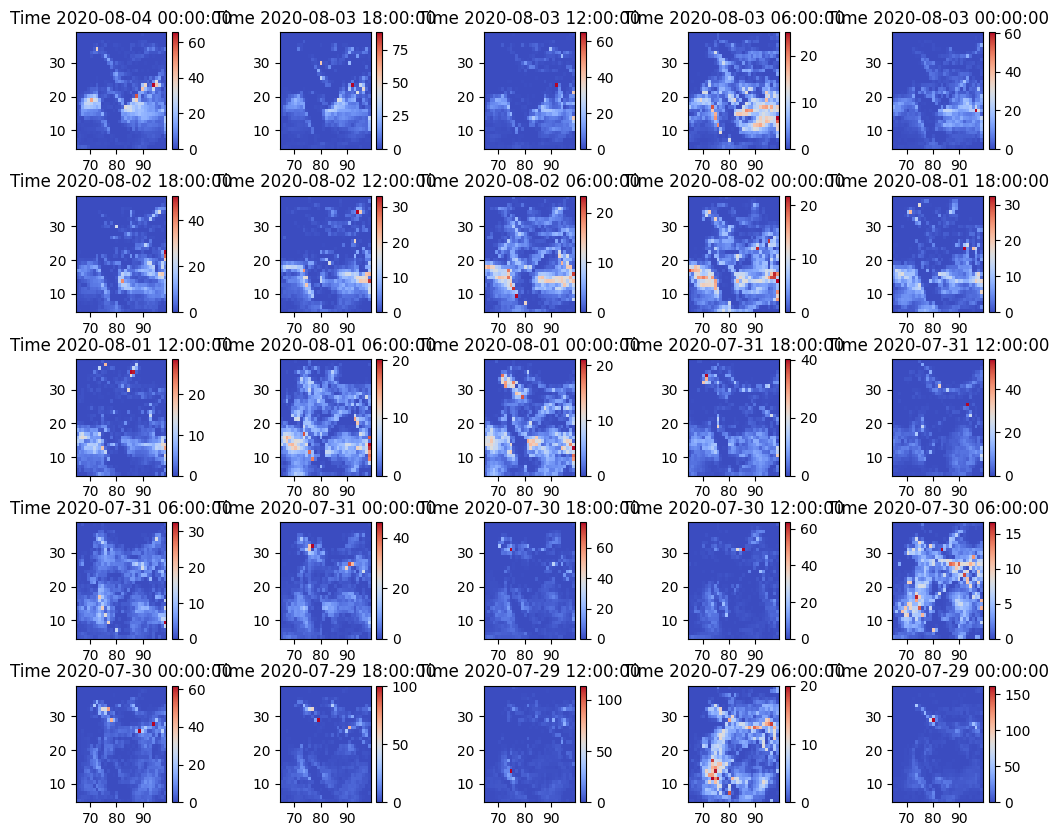

In [79]:
fig, axes = plt.subplots(5, 5, figsize=(12, 10))
plt.subplots_adjust(wspace=0.8, hspace=0.4)
for ax in axes.flatten():
    tmp = ds.variables['APCP_sfc'][index].data
    lon_grid, lat_grid = np.meshgrid(ds.variables['lon'][:].data, ds.variables['lat'][:].data)
    im = ax.pcolormesh(lon_grid, lat_grid, tmp, shading='auto', cmap='coolwarm')
    ax.set_title(f'Time {str(dates[index])}')
    index -= 1
    fig.colorbar(im, ax=ax)


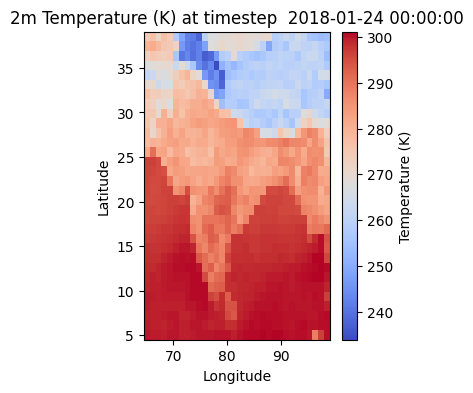

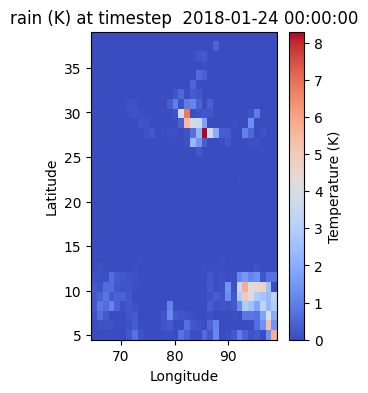

In [63]:
temp_image(ds,41000)
rain_image(ds,41000)

In [34]:
city_data = [
    [28.6139, 77.2090, "Delhi"],
    [19.0760, 72.8777, "Mumbai"],
    [22.5726, 88.3639, "Kolkata"],
    [13.0827, 80.2707, "Chennai"],
    [12.9716, 77.5946, "Bengaluru"],
    [17.3850, 78.4867, "Hyderabad"],
    [18.5204, 73.8567, "Pune"],
    [23.0225, 72.5714, "Ahmedabad"],
    [26.9124, 75.7873, "Jaipur"],
    [26.8467, 80.9462, "Lucknow"],
    [23.2599, 77.4126, "Bhopal"],
    [25.5941, 85.1376, "Patna"],
    [21.1458, 79.0882, "Nagpur"],
    [30.7333, 76.7794, "Chandigarh"],
    [8.5241, 76.9366, "Thiruvananthapuram"],
    [34.0837, 74.7973, "Srinagar"]
]


In [35]:
def closest(df:pd.DataFrame,lat:float,lon:float,name):
    lat_idx = np.argmin(abs(df['lat']-lat))
    lon_idx = np.argmin(abs(df['lon']-lon))
    print(f"the closest latitude is {df['lat'][lat_idx]} and longitude is {df['lon'][lon_idx]} to {name}")

In [36]:
for i in city_data:
    closest(df,i[0],i[1],i[2])

the closest latitude is 28.8 and longitude is 76.91999999999999 to Delhi
the closest latitude is 19.080000000000002 and longitude is 72.6 to Mumbai
the closest latitude is 22.32 and longitude is 88.79999999999997 to Kolkata
the closest latitude is 12.600000000000001 and longitude is 80.15999999999998 to Chennai
the closest latitude is 12.600000000000001 and longitude is 77.99999999999999 to Bengaluru
the closest latitude is 16.92 and longitude is 77.99999999999999 to Hyderabad
the closest latitude is 18.0 and longitude is 73.67999999999999 to Pune
the closest latitude is 23.4 and longitude is 72.6 to Ahmedabad
the closest latitude is 26.64 and longitude is 75.83999999999999 to Jaipur
the closest latitude is 26.64 and longitude is 81.23999999999998 to Lucknow
the closest latitude is 23.4 and longitude is 76.91999999999999 to Bhopal
the closest latitude is 25.560000000000002 and longitude is 85.55999999999997 to Patna
the closest latitude is 21.240000000000002 and longitude is 79.0799999

In [55]:
ds.variables['TMP_2m']

<class 'netCDF4.Variable'>
float32 TMP_2m(time, latitude, longitude)
    _FillValue: nan
    long_name: Temperature
    units: K
    short_name: TMP_2maboveground
    level: 2 m above ground
    coordinates: lon lat
unlimited dimensions: 
current shape = (45292, 32, 32)
filling on